In [87]:
import numpy as np
import math
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.layers as tfl
import scipy
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
np.random.seed(1)

In [88]:
def load_dataset():
    train_dataset=h5py.File("Dataset/train_happy.h5",'r')
    train_X = np.array(train_dataset["train_set_x"][:])
    train_y = np.array(train_dataset["train_set_y"][:])

    test_dataset = h5py.File("Dataset/test_happy.h5","r")
    test_X=np.array(test_dataset["test_set_x"][:])
    test_y = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    train_y = train_y.reshape((1,train_y.shape[0]))
    test_y=test_y.reshape((1,test_y.shape[0]))

    return train_X, train_y, test_X, test_y, classes
    

In [89]:
train_X,train_y,test_X,test_y,classes = load_dataset()

In [90]:
train_X.shape, train_y.shape, test_X.shape, test_y.shape, classes.shape

((600, 64, 64, 3), (1, 600), (150, 64, 64, 3), (1, 150), (2,))

In [91]:
train_X_norm,test_X_norm = train_X/255.0,test_X/255.0
train_y,test_y=train_y.T,test_y.T

X_train, X_val, y_train, y_val = train_test_split(
    train_X_norm, 
    train_y, 
    test_size=0.20,      # 20% of the data goes to validation
    random_state=42,     # Ensures you get the exact same split every time you run the code
    stratify=train_y     # VERY IMPORTANT: Ensures the ratio of "Happy" to "Not Happy" stays the same in both sets
)

In [92]:
print("Number of training examples: ",X_train.shape[0])
print("Number of validation examples: ",X_val.shape[0])
print("Number of test examples: ", test_X_norm.shape[0])
print("train_X_norm shape: ", X_train.shape)
print("Val_X_norm shape: ", X_val.shape)
print("test_X_norm shape: ", test_X_norm.shape)
print("Number of Classes: ", classes[0])
print("y_train shape: ", y_train.shape)
print("y_val shape: ", y_val.shape)
print("test_y shape: ", test_y.shape)

Number of training examples:  480
Number of validation examples:  120
Number of test examples:  150
train_X_norm shape:  (480, 64, 64, 3)
Val_X_norm shape:  (120, 64, 64, 3)
test_X_norm shape:  (150, 64, 64, 3)
Number of Classes:  0
y_train shape:  (480, 1)
y_val shape:  (120, 1)
test_y shape:  (150, 1)


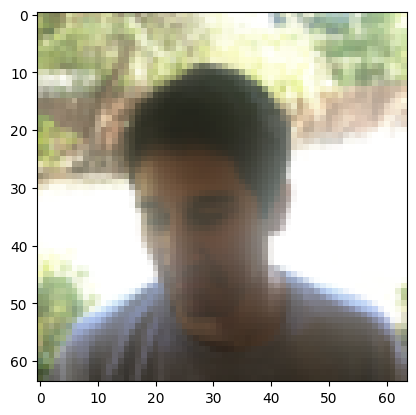

In [93]:
index = 130
plt.imshow(train_X[index]) #display sample training image

plt.show()


In [94]:
# # Model layer Architecture
# ZeroPadding2D: padding 3, input shape 64 x 64 x 3
# Conv2D: Use 32 7x7 filters, stride 1
# BatchNormalization: for axis 3
# ReLU
# DRopout - can be skipped as it is a small model with not very large dataset.
# MaxPool2D: Using default parameters
# Flatten the previous output.
# Fully-connected (Dense) layer: 
# Fully connected (Dense) layer:

def HappynessClassifier():
    model = tf.keras.Sequential([
        tfl.Input(shape =(64,64,3)),

        tfl.RandomFlip("horizontal"),
        tfl.RandomRotation(0.1),
        tfl.RandomZoom(0.1),

        
        tfl.ZeroPadding2D(padding =(3,3), input_shape=(64,64,3)),
        tfl.Conv2D(strides = (1,1), filters = 32, kernel_size =(7,7)),
        tfl.BatchNormalization(axis =3),
        tfl.ReLU(),
        tfl.MaxPool2D(),
        tfl.Flatten(),
        tfl.Dense(units=128,activation = 'relu'),
        # tfl.Dropout(rate=0.4),
        tfl.Dense(activation = "sigmoid", units =1),
    ]
                               )
    return model
    
                                

In [95]:
happyness_classifier = HappynessClassifier()
happyness_classifier.summary()

/home/dikshant/miniconda3/envs/ml-fundamentals/lib/python3.10/site-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_10               │ (None, 70, 70, 3)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,199,425 (16.02 MB)

 Trainable params: 4,199,361 (16.02 MB)

 Non-trainable params: 64 (256.00 B)

In [96]:
happyness_classifier.compile(optimizer=Adam(learning_rate=0.0001),
                             loss = 'binary_crossentropy',
                             metrics = ["accuracy"],
                            )

In [97]:
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
history = happyness_classifier.fit(X_train, 
                                   y_train, 
                                   epochs=100, 
                                   batch_size=16, 
                                   validation_data=(X_val, y_val),
                                   callbacks=[early_stop, reduce_lr]
                                  )

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.5750 - loss: 0.8128 - val_accuracy: 0.5250 - val_loss: 0.6855 - learning_rate: 1.0000e-04
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6708 - loss: 0.6368 - val_accuracy: 0.5333 - val_loss: 0.6729 - learning_rate: 1.0000e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6271 - loss: 0.6961 - val_accuracy: 0.6417 - val_loss: 0.6388 - learning_rate: 1.0000e-04
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6646 - loss: 0.6770 - val_accuracy: 0.6250 - val_loss: 0.6277 - learning_rate: 1.0000e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7354 - loss: 0.5241 - val_accuracy: 0.7583 - val_loss: 0.5855 - learning_rate: 1.0000e-04
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7292 - loss: 0.5296 - val_accuracy: 0.7167 - val_loss: 0.5909 - learning_rate: 1.0000e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 

In [98]:
happyness_classifier.evaluate(test_X_norm,test_y)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8867 - loss: 0.2825


[0.28249308466911316, 0.8866666555404663]

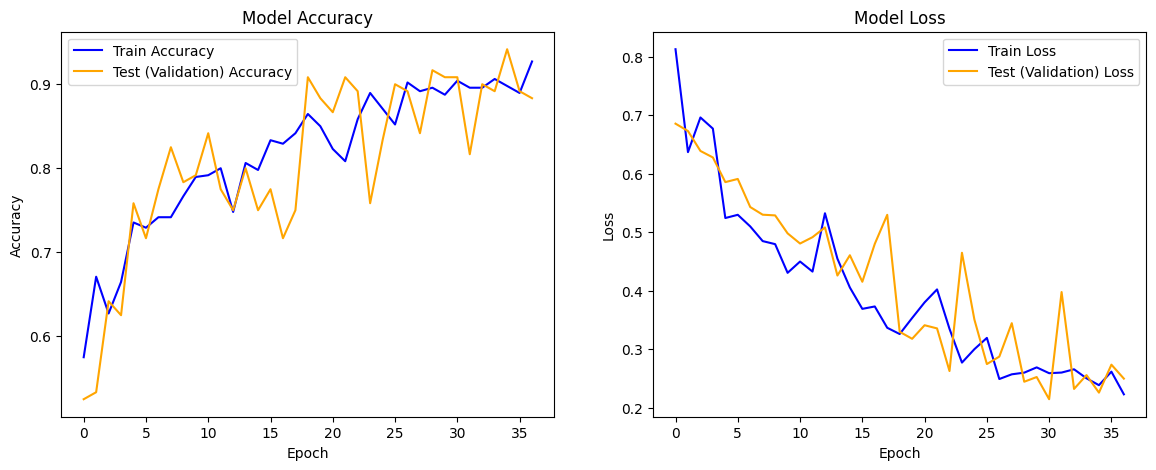

In [99]:
# 2. Plot the loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Test (Validation) Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Test (Validation) Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


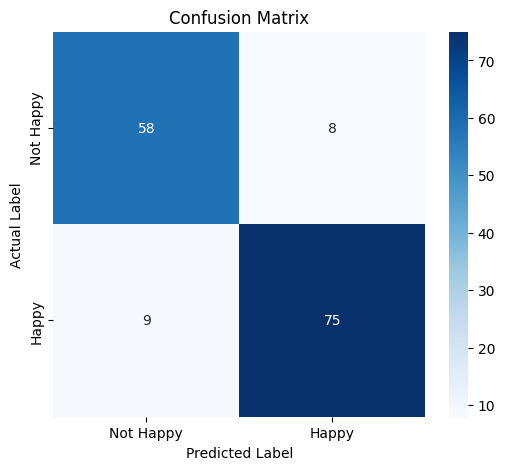


Classification Report:
              precision    recall  f1-score   support

   Not Happy       0.87      0.88      0.87        66
       Happy       0.90      0.89      0.90        84

    accuracy                           0.89       150
   macro avg       0.88      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



In [100]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get raw probability predictions from the model
predictions = happyness_classifier.predict(test_X_norm)

# 2. Convert probabilities to binary class labels (0 or 1) using a 0.5 threshold
predicted_classes = (predictions > 0.5).astype(int)

# 3. Generate the confusion matrix
cm = confusion_matrix(test_y, predicted_classes)

# 4. Plot it using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Happy', 'Happy'], 
            yticklabels=['Not Happy', 'Happy'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Print the classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(test_y, predicted_classes, target_names=['Not Happy', 'Happy']))

Total misclassified images: 17


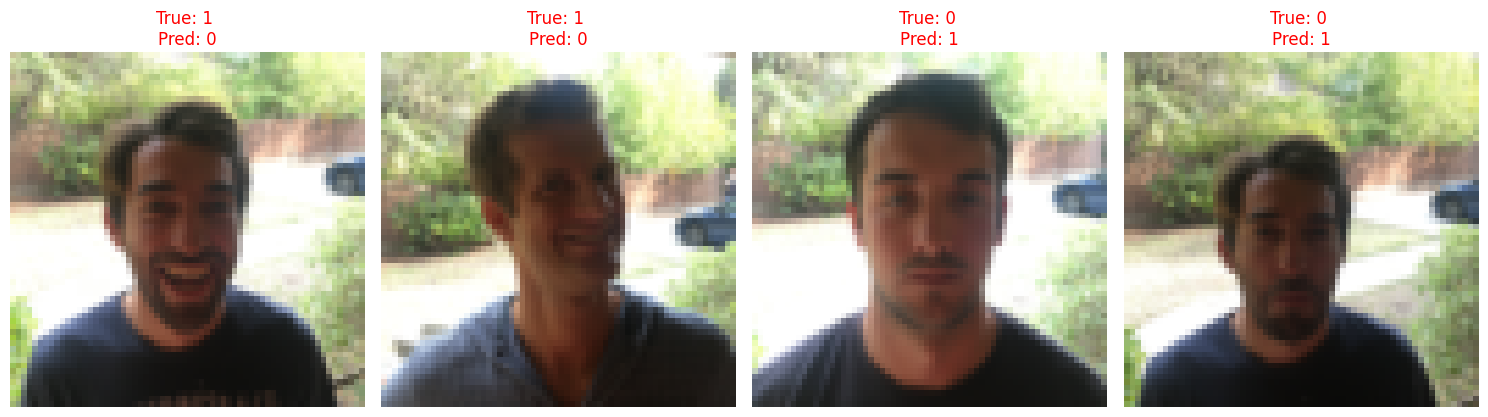

In [101]:
# Find the indices where the prediction does NOT match the actual label
# Note: we use flatten() to ensure both arrays are 1D before comparing
misclassified_indices = np.where(predicted_classes.flatten() != test_y.flatten())[0]

print(f"Total misclassified images: {len(misclassified_indices)}")

# Plot the first 4 misclassified images
plt.figure(figsize=(15, 4))
for i, index in enumerate(misclassified_indices[:4]):
    plt.subplot(1, 4, i + 1)
    
    # We use the UN-NORMALIZED images (test_X) for displaying so the colors look right
    plt.imshow(test_X[index]) 
    
    actual_label = test_y.flatten()[index]
    predicted_label = predicted_classes.flatten()[index]
    
    plt.title(f"True: {actual_label} \nPred: {predicted_label}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()